# Local Outlier Factor (LOF) for DDoS Detection - Revised

### Key Changes in this Version:
1. **Balanced Test Set:** Downsampled the DDoS test samples to exactly match the number of Benign test samples. This prevents the massive DDoS class from masking false positives and skewing the overall Accuracy and F1-Score.
2. **Realistic Contamination Thresholds:** Lowered the `contamination` search grid values. Because the model is trained *only* on normal traffic, high contamination values (like 0.1) force the model to flag 10% of normal traffic as attacks. We now test `0.001` to `0.05`.
3. **FPR-Aware Evaluation:** Replaced generic Precision/Recall with **False Positive Rate (FPR)** and **DDoS Detection Rate**. In network security, keeping the FPR close to 0% is often more critical than a slight boost in detecting anomalies.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score
)

In [3]:
# Load the dataset
df = pd.read_csv("../data/ddos_clean.csv")

# Create binary anomaly label (1 for DDoS, 0 for BENIGN)
df["Anomaly"] = (df[" Label"] != "BENIGN").astype(int)

# Separate features and target
X = df.drop([" Label", "Anomaly"], axis=1)
y_true = df["Anomaly"]

print("Dataset shape:", df.shape)
print(y_true.value_counts())

Dataset shape: (225711, 44)
Anomaly
1    128025
0     97686
Name: count, dtype: int64


In [4]:
# Separate BENIGN and DDoS samples
X_benign = X[y_true == 0]
X_ddos = X[y_true == 1]

# Split BENIGN data: 70% for training, 30% for testing
X_benign_train, X_benign_test = train_test_split(
    X_benign, test_size=0.3, random_state=42
)

# REVISION 1: Balance the test set by subsampling the massive DDoS class
# We match the number of DDoS test samples to the number of Benign test samples
X_ddos_test = X_ddos.sample(n=len(X_benign_test), random_state=42)

print("BENIGN training samples:", X_benign_train.shape)
print("BENIGN test samples:", X_benign_test.shape)
print("DDoS test samples (Balanced):", X_ddos_test.shape)

BENIGN training samples: (68380, 42)
BENIGN test samples: (29306, 42)
DDoS test samples (Balanced): (29306, 42)


In [5]:
# Fit scaler ONLY on BENIGN training data (prevents data leakage)
scaler = StandardScaler()
scaler.fit(X_benign_train)

# Transform all sets using the scaler fitted on training data only
X_train_scaled = scaler.transform(X_benign_train)
X_benign_test_scaled = scaler.transform(X_benign_test)
X_ddos_test_scaled = scaler.transform(X_ddos_test)

# Build the BALANCED test set
X_test_balanced = np.vstack([X_benign_test_scaled, X_ddos_test_scaled])
y_test_balanced = np.concatenate([
    np.zeros(len(X_benign_test_scaled)),
    np.ones(len(X_ddos_test_scaled))
]).astype(int)

print("Final training set (BENIGN only):", X_train_scaled.shape)
print("Final balanced test set:", X_test_balanced.shape)

Final training set (BENIGN only): (68380, 42)
Final balanced test set: (58612, 42)


In [6]:
def evaluate_lof(n_neighbors, contamination, X_train, X_test, y_test):
    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        novelty=True,
        contamination=contamination
    )
    model.fit(X_train)

    y_pred = (model.predict(X_test) == -1).astype(int)

    # Extract confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # REVISION 3: Calculate security-focused metrics
    fpr = fp / (fp + tn)                  # False Positive Rate (Alarm Fatigue)
    benign_acc = tn / (tn + fp)           # Specificity
    ddos_detection_rate = tp / (tp + fn)  # Sensitivity / Recall for DDoS
    f1 = f1_score(y_test, y_pred)

    return {
        "n_neighbors": n_neighbors,
        "contamination": contamination,
        "FPR": fpr,
        "Benign_Acc": benign_acc,
        "DDoS_Detection_Rate": ddos_detection_rate,
        "Balanced_F1": f1
    }

In [7]:
# REVISION 2: Tune with realistic, low contamination rates 
# Since training data is 100% normal, expected outliers are near 0%.
neighbors_list = [20, 50, 100]
contamination_list = [0.001, 0.005, 0.01, 0.05]

results = []

for n in neighbors_list:
    for c in contamination_list:
        print(f"Testing n_neighbors={n}, contamination={c}...")
        res = evaluate_lof(n, c, X_train_scaled, X_test_balanced, y_test_balanced)
        results.append(res)

Testing n_neighbors=20, contamination=0.001...
Testing n_neighbors=20, contamination=0.005...
Testing n_neighbors=20, contamination=0.01...
Testing n_neighbors=20, contamination=0.05...
Testing n_neighbors=50, contamination=0.001...
Testing n_neighbors=50, contamination=0.005...
Testing n_neighbors=50, contamination=0.01...
Testing n_neighbors=50, contamination=0.05...
Testing n_neighbors=100, contamination=0.001...
Testing n_neighbors=100, contamination=0.005...
Testing n_neighbors=100, contamination=0.01...
Testing n_neighbors=100, contamination=0.05...


In [8]:
summary = pd.DataFrame(results)
summary["FPR"] = (summary["FPR"] * 100).round(2).astype(str) + "%"
summary["Benign_Acc"] = summary["Benign_Acc"].round(4)
summary["DDoS_Detection_Rate"] = summary["DDoS_Detection_Rate"].round(4)
summary["Balanced_F1"] = summary["Balanced_F1"].round(4)

# Display results, prioritizing models with the highest Balanced F1 but keeping an eye on FPR
print("Parameter Grid Results (Sorted by Balanced F1):")
print(summary.sort_values(by="Balanced_F1", ascending=False).reset_index(drop=True))

Parameter Grid Results (Sorted by Balanced F1):
    n_neighbors  contamination    FPR  Benign_Acc  DDoS_Detection_Rate  \
0            20          0.050  5.11%      0.9489               0.8596   
1            50          0.050  5.09%      0.9491               0.7105   
2           100          0.050  4.98%      0.9502               0.6878   
3           100          0.010  1.05%      0.9895               0.0027   
4            50          0.010  0.98%      0.9902               0.0006   
5            20          0.010   1.0%      0.9900               0.0005   
6            20          0.005   0.4%      0.9960               0.0003   
7            50          0.005  0.45%      0.9955               0.0001   
8           100          0.005  0.52%      0.9948               0.0000   
9            20          0.001  0.08%      0.9992               0.0000   
10           50          0.001  0.04%      0.9996               0.0000   
11          100          0.001  0.11%      0.9989               


Training final LOF model with n_neighbors=20, contamination=0.05

Final Classification Report (Balanced Unseen Test Set):
              precision    recall  f1-score   support

  BENIGN (0)       0.87      0.95      0.91     29306
    DDoS (1)       0.94      0.86      0.90     29306

    accuracy                           0.90     58612
   macro avg       0.91      0.90      0.90     58612
weighted avg       0.91      0.90      0.90     58612



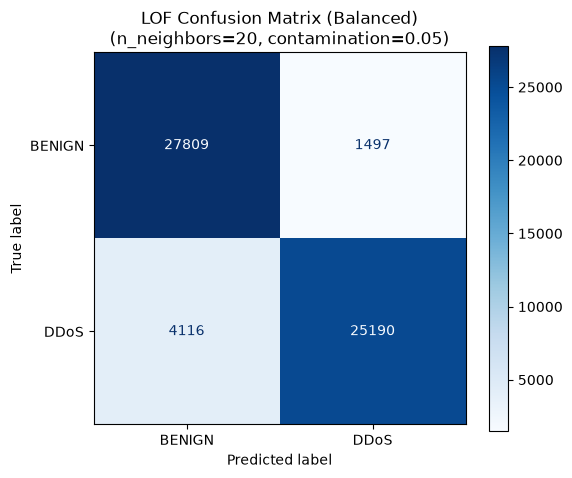

In [9]:
# Select the best model balancing high Detection Rate with a very low FPR.
# You can adjust the iloc[0] to pick a model with specifically lower FPR if desired.
best_params = summary.sort_values(by="Balanced_F1", ascending=False).iloc[0]
best_n = int(best_params["n_neighbors"])
best_c = best_params["contamination"]

print(f"\nTraining final LOF model with n_neighbors={best_n}, contamination={best_c}")

best_lof = LocalOutlierFactor(n_neighbors=best_n, novelty=True, contamination=best_c)
best_lof.fit(X_train_scaled)
y_pred_balanced = (best_lof.predict(X_test_balanced) == -1).astype(int)

print("\nFinal Classification Report (Balanced Unseen Test Set):")
print(classification_report(y_test_balanced, y_pred_balanced, target_names=["BENIGN (0)", "DDoS (1)"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_balanced, y_pred_balanced, display_labels=["BENIGN", "DDoS"],
    cmap="Blues", values_format='d', ax=ax
)
plt.title(f"LOF Confusion Matrix (Balanced)\n(n_neighbors={best_n}, contamination={best_c})")
plt.show()